In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Path to the 5-pt checkpoint (whichever ckpt file was live during the 5-pt run)
CKPT_PATH   = 'ckpt_1192k_oh_train_5pts.pt'   # adjust if wrong
RESULT_PATH = 'result_1192k_oh_relu_train.pt'  # 5-pt trained model
HIDDEN_DIM  = 16
INPUT_DIM   = 4


In [2]:
ckpt  = torch.load(CKPT_PATH, weights_only=False)
Y_raw = np.array(ckpt['y_list'])   # shape (N, n_out)
X_raw = np.array(ckpt['x_list'])   # shape (N, 4)
n_out_ckpt = Y_raw.shape[1]
print(f'Checkpoint: X={X_raw.shape}  Y={Y_raw.shape}')

# Infer labels from checkpoint or fall back to generic
if 'target_labels' in ckpt:
    LABELS = ckpt['target_labels']
elif n_out_ckpt == 5:
    LABELS = ['rise (50% up)', '[OH]_peak', 't_peak', 'OH @ 2·t_peak', 'OH @ 5·t_peak']
else:
    LABELS = ['rise (50% up)', '[OH]_peak', 'OH @ 2·t_peak', 'OH @ 5·t_peak']

print(f'Columns ({n_out_ckpt}): {LABELS}')
Y_log = np.log(Y_raw + 1e-12)


Checkpoint: X=(40000, 4)  Y=(40000, 5)
Columns (5): ['rise (50% up)', '[OH]_peak', 't_peak', 'OH @ 2·t_peak', 'OH @ 5·t_peak']


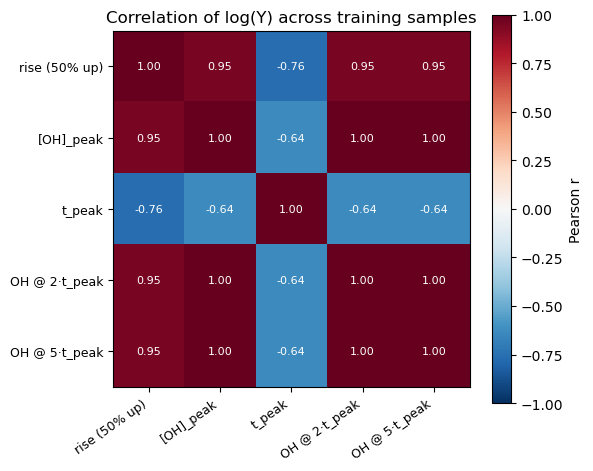

Correlations with t_peak (col 2):
  t_peak <-> rise (50% up)           r = -0.764
  t_peak <-> [OH]_peak               r = -0.637
  t_peak <-> OH @ 2·t_peak           r = -0.636
  t_peak <-> OH @ 5·t_peak           r = -0.640

Max |r| with t_peak = 0.764
Verdict: INDEPENDENT (keep)


In [3]:
# ── Test 1: correlation matrix of log(Y) ─────────────────────────────────
corr = np.corrcoef(Y_log.T)   # n_out × n_out

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(n_out_ckpt)); ax.set_xticklabels(LABELS, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(n_out_ckpt)); ax.set_yticklabels(LABELS, fontsize=9)
for i in range(n_out_ckpt):
    for j in range(n_out_ckpt):
        ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(corr[i,j]) > 0.6 else 'black')
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_title('Correlation of log(Y) across training samples')
plt.tight_layout(); plt.show()

if n_out_ckpt == 5:
    print('Correlations with t_peak (col 2):')
    for j, lbl in enumerate(LABELS):
        if j != 2:
            print(f'  t_peak <-> {lbl:<22}  r = {corr[2,j]:+.3f}')
    r_max = max(abs(corr[2, j]) for j in range(5) if j != 2)
    print(f'\nMax |r| with t_peak = {r_max:.3f}')
    verdict = 'REDUNDANT (safe to drop)' if r_max > 0.95 else \
              'BORDERLINE' if r_max > 0.85 else 'INDEPENDENT (keep)'
    print('Verdict:', verdict)
else:
    print('(t_peak not in this checkpoint — 4-pt model)')


In [4]:
# ── Test 2: Jacobian condition number at x=0 ──────────────────────────────
# The trained model always has 5 outputs (t_peak included); we compare
# condition numbers of the information matrix with vs. without the t_peak row.
N_MODEL = 5   # outputs of the trained 5-pt model
LABELS5 = ['rise (50% up)', '[OH]_peak', 't_peak', 'OH @ 2·t_peak', 'OH @ 5·t_peak']

class SurrogateNN(nn.Module):
    def __init__(self, hidden=HIDDEN_DIM, n_out=N_MODEL):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(INPUT_DIM, hidden), nn.ReLU(),
            nn.Linear(hidden, n_out))
    def forward(self, x): return self.net(x)

bundle = torch.load(RESULT_PATH, weights_only=False)
model  = SurrogateNN()
model.load_state_dict(bundle['model_state'])
model.eval()
print(f'Loaded: {RESULT_PATH}')

x0 = torch.zeros(1, INPUT_DIM)
J_full = torch.autograd.functional.jacobian(
    lambda x: model(x).squeeze(0), x0
).detach().numpy().reshape(N_MODEL, INPUT_DIM)

print('\nJacobian at x=0 (rows=outputs, cols=lnA_R22/Ea_R22/lnA_R26/Ea_R26):')
for j, lbl in enumerate(LABELS5):
    row = '  '.join(f'{v:+7.4f}' for v in J_full[j])
    print(f'  {j+1}. {lbl:<22}  {row}')


Loaded: result_1192k_oh_relu_train.pt

Jacobian at x=0 (rows=outputs, cols=lnA_R22/Ea_R22/lnA_R26/Ea_R26):
  1. rise (50% up)           +9.0278  -1.9080  -2.9478  +0.6222
  2. [OH]_peak               +7.9358  -1.6747  -6.8411  +1.4447
  3. t_peak                  -2.0041  +0.4212  -5.6801  +1.1970
  4. OH @ 2·t_peak           +8.1251  -1.7143  -7.2140  +1.5220
  5. OH @ 5·t_peak           +8.3374  -1.7574  -8.0682  +1.6992


In [5]:
def hessian_cond(J):
    H = J.T @ J
    eigs = np.linalg.eigvalsh(H)
    return eigs[-1] / max(eigs[0], 1e-30), eigs

cond_full, eigs_full = hessian_cond(J_full)
print(f'Full 5-pt  cond(H) = {cond_full:.3e}   eigenvalues: {np.round(np.sort(eigs_full), 6)}')

print('\nCondition number when each probe is dropped:')
for drop_j, lbl in enumerate(LABELS5):
    J_sub = np.delete(J_full, drop_j, axis=0)
    cond_sub, _ = hessian_cond(J_sub)
    ratio = cond_sub / cond_full
    flag = '  <- negligible loss' if ratio < 2.0 else '  <- significant loss'
    print(f'  drop "{lbl}": cond = {cond_sub:.3e}  ratio = {ratio:.2f}{flag}')

J_no_tpk = np.delete(J_full, 2, axis=0)
cond_no_tpk, _ = hessian_cond(J_no_tpk)
ratio_tpk = cond_no_tpk / cond_full
print(f'\nDropping t_peak: cond ratio = {ratio_tpk:.2f}')
print('Verdict:', 'SAFE to drop (< 2x)' if ratio_tpk < 2.0 else
      'BORDERLINE (2-5x)' if ratio_tpk < 5.0 else 'COSTLY to drop (> 5x)')


Full 5-pt  cond(H) = 9.225e+07   eigenvalues: [4.9999999e-06 1.7000000e-05 4.7096096e+01 4.6357819e+02]

Condition number when each probe is dropped:
  drop "rise (50% up)": cond = 3.846e+32  ratio = 4168668724522803160678400.00  <- significant loss
  drop "[OH]_peak": cond = 1.044e+08  ratio = 1.13  <- negligible loss
  drop "t_peak": cond = 3.886e+08  ratio = 4.21  <- significant loss
  drop "OH @ 2·t_peak": cond = 5.872e+07  ratio = 0.64  <- negligible loss
  drop "OH @ 5·t_peak": cond = 4.035e+08  ratio = 4.37  <- significant loss

Dropping t_peak: cond ratio = 4.21
Verdict: BORDERLINE (2-5x)


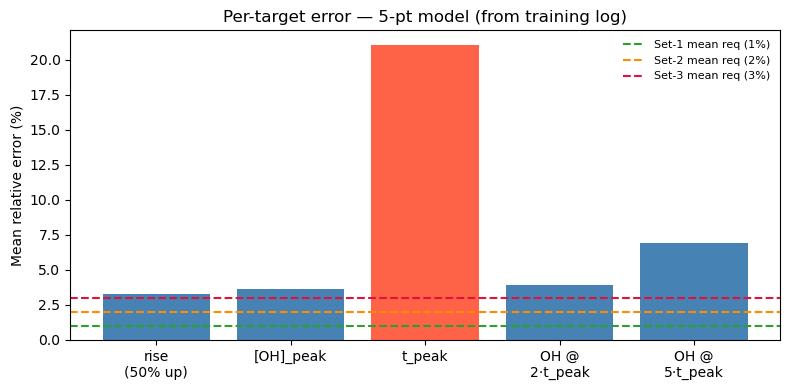

Conclusion:
  t_peak error (21%) is 5-7x higher than all other probes (3-7%).
  It prevents the remaining 4 probes from meeting Zhang Table 1.
  Decision: drop t_peak -> retrain as 4-pt model.


In [6]:
# ── Summary: per-target error from training log ───────────────────────────
log_labels = ['rise\n(50% up)', '[OH]_peak', 't_peak', 'OH @\n2·t_peak', 'OH @\n5·t_peak']
log_errors = [3.29, 3.65, 21.05, 3.93, 6.94]   # from 1192_oh_relu_train_log.log

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['tomato' if e > 10 else 'steelblue' for e in log_errors]
ax.bar(log_labels, log_errors, color=colors)
ax.axhline(1,  color='#2ca02c', ls='--', lw=1.5, label='Set-1 mean req (1%)')
ax.axhline(2,  color='darkorange', ls='--', lw=1.5, label='Set-2 mean req (2%)')
ax.axhline(3,  color='crimson',    ls='--', lw=1.5, label='Set-3 mean req (3%)')
ax.set_ylabel('Mean relative error (%)')
ax.set_title('Per-target error — 5-pt model (from training log)')
ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

print('Conclusion:')
print('  t_peak error (21%) is 5-7x higher than all other probes (3-7%).')
print('  It prevents the remaining 4 probes from meeting Zhang Table 1.')
print('  Decision: drop t_peak -> retrain as 4-pt model.')
